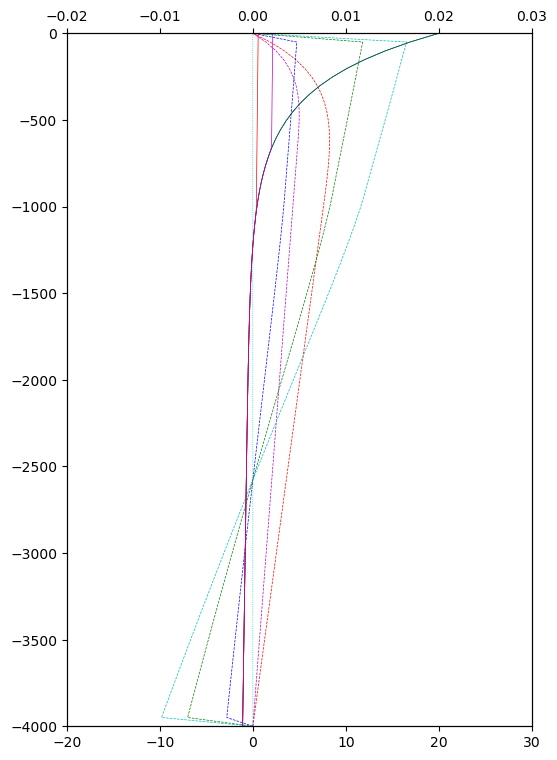

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_11146/262466297.py:438: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_11146/262466297.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


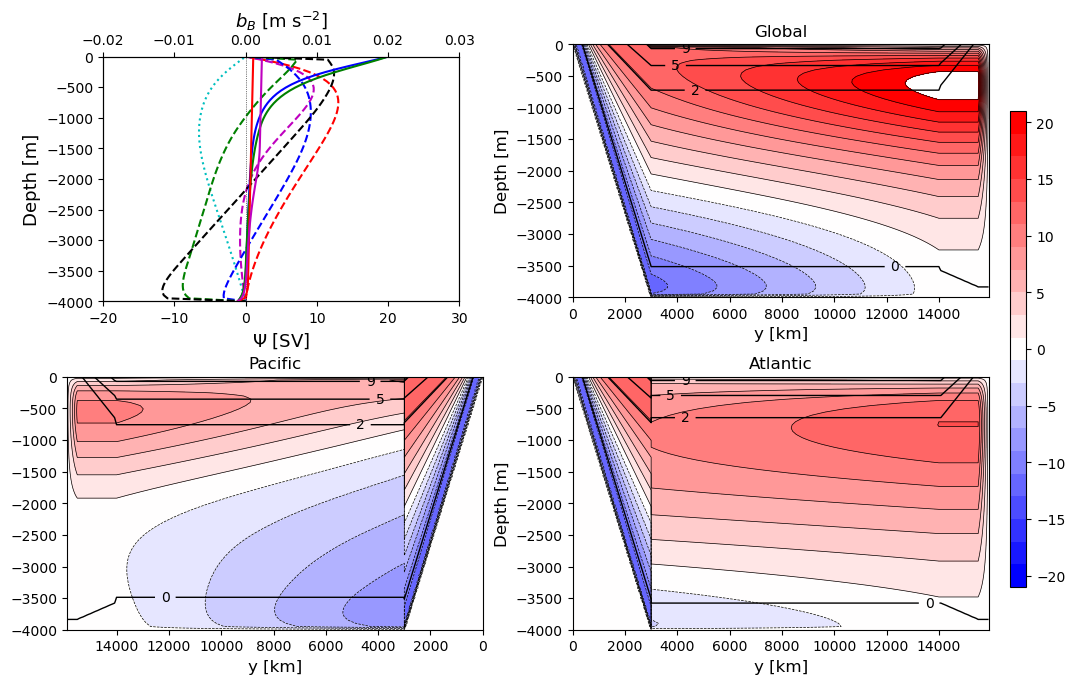

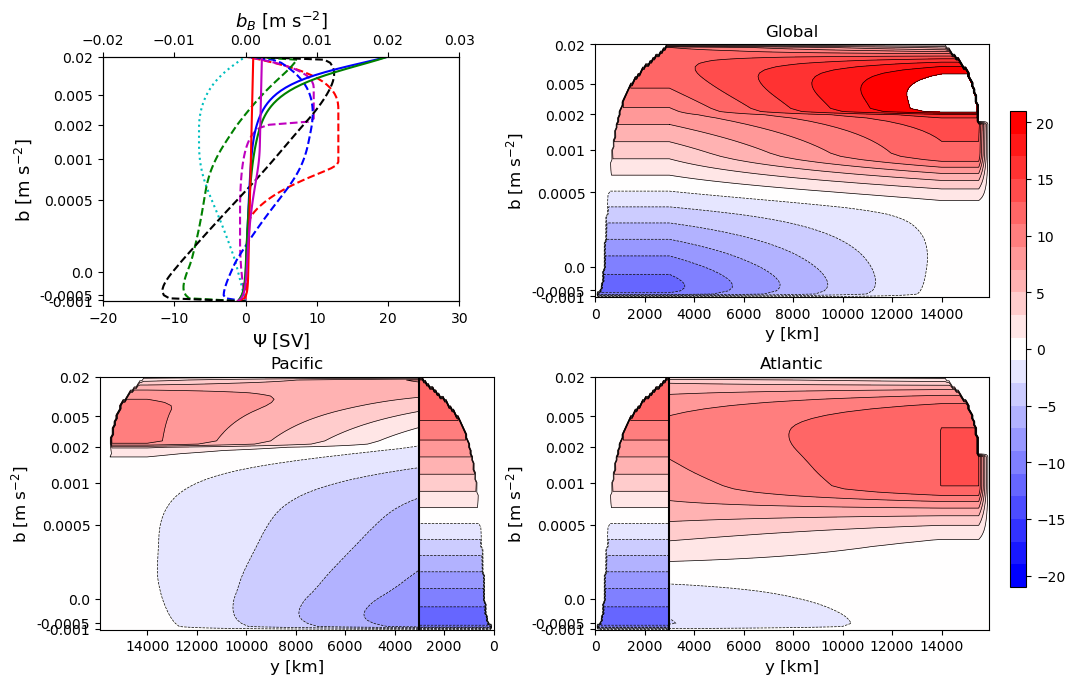

In [4]:
"""
Four-column MOC model, allowing for Northern sinking in the Pacific and the development of a PMOC.
"""

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file = None



#!!!
# bs_north_pac_vals = [0.0005,  0.005,  0.02] 
bs_north_pac_vals = [0.002] #, 0.00036] 


for bs_north_pac in bs_north_pac_vals:
    bs = 0.02;
    # the minimum surface buoyancy in the GCM in the North Atlantic is 3.5890e-04 (or 0.1795C)
    bs_north = 0.00036
    bAABW = -0.0011  # x1
    # bAABW = -0.0044  # x4
    
    bbot = min(bAABW, bs_north, bs_north_pac)

    # S.O. surface boundary conditions and grid:
    y = np.asarray(np.linspace(0, 3.e6, 51))
    tau = 0.16 # original 
    tau = 0.2
    offset = 0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6));
    bs_SO = (0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
          +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5));

    # time-stepping parameters:
    dt = 86400.*30.                               # time-step for vert. adv. diff. calc.
    MOC_up_iters = int(np.floor(2.*360*86400/dt)) # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
    plot_iters = int(np.ceil(500*360*86400/dt))   # plotting frequency (in iterations)
    total_iters = int(np.ceil(4000*360*86400/dt)) # total number of timesteps

    # Effective diffusivity profile          #original
    def kappaeff(z): # effective diffusivity profile with tapering in BBL
            return 1.0*( 1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
                    *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )

    # def kappaeff(z): # effective diffusivity profile with tapering in BBL
    #         return 1.0*( 3e-5*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
    #                 *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )
        
    # kappa = 3e-5 based on the quasi-constant (in the vertical) diffusivity inferred by Kunze (2017)
    # kappaeff = 3e-5 

    
    # a κ based on the bulk basin-wide estimate of Lumpkin and Speer (2007)
    

    A_Atl = 7e13#6e13  
    A_north_atl = 5.5e12
    # A_Pac = 1.7e14 #1.44e14      #old
    
    A_Pac = 1.7e14 - 5.5e12            #new
    A_north_pac = 5.5e12 #new 5.5e12
    
    Lx = 1.3e+07  #(length of the channel)
    Latl = 6./21.*Lx;
    Lpac = 15./21.*Lx;
    K = 1800.
    N2min = 2e-7
    
    z = np.asarray(np.linspace(-4000, 0, 80))
    
    # create initial guess for buoyancy profile in the Atl
    def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
    #def b_Atl(z): return 0.3*bs+z/z[0]*(bbot-0.3*bs)
    def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

    # create N.A. overturning model instance
    AMOC = Psi_Thermwind(z=z, b1=b_Atl, b2=0.01*b_Atl(z))
    # and solve for initial overturning streamfunction:
    AMOC.solve()
    # map North Atlantic overturning to isopycnal space:
    [Psi_iso_Atl, Psi_iso_N] = AMOC.Psibz()
    ####
    
    # create Pacific overturning model instance (PMOC) for North Pacific sinking
    PMOC = Psi_Thermwind(z=z, b1=b_Pac, b2=0.01*b_Pac(z))
    
    PMOC.solve()
    [Psi_iso_Pac, Psi_iso_NPac] = PMOC.Psibz()
    
    # create interbasin zonal overturning model instance
    ZOC = Psi_Thermwind(z=z, b1=b_Atl, b2=b_Pac, f=1e-4)
    # and solve for initial overturning streamfunction:
    ZOC.solve()
    # map inter-basin overturning to isopycnal space:
    [Psi_zonal_Atl, Psi_zonal_Pac] = ZOC.Psibz()
    
    # create S.O. overturning model instance for Atlantic sector
    SO_Atl = Psi_SO(z=z, y=y, b=b_Atl(z), bs=bs_SO, tau=tau, L=Latl, KGM=K)
    SO_Atl.solve()
    
    # create S.O. overturning model instance for Pacific sector
    SO_Pac = Psi_SO(z=z, y=y, b=b_Pac(z), bs=bs_SO, tau=tau, L=Lpac, KGM=K)
    SO_Pac.solve()

    
    
    # create adv-diff column model instance for Atl
    Atl = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs, bbot=bbot, Area=A_Atl, N2min=N2min)
    # create adv-diff column model instance for northern sinking region (Atlantic)
    north = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs_north, bbot=bbot, Area=A_north_atl, N2min=N2min)
    # create adv-diff column model instance for Pac
    Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs, bbot=bbot, Area=A_Pac, N2min=N2min)
    # create adv-diff column model instance for northern Pacific sinking region
    ####### !!!!
    north_Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs_north_pac, bbot=bbot, Area=A_north_pac, N2min=N2min)
    
    # Create figure:
    fig = plt.figure(figsize=(6,9))
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twiny()
    plt.ylim((-4e3,0))
    ax1.set_xlim((-20,30))
    ax2.set_xlim((-0.02,0.030))
    
    # loop to iteratively find equilibrium solution
    for ii in range(0, total_iters):    
       # update buoyancy profile
       # using isopycnal overturning:
       wA_Atl = (Psi_iso_Atl + Psi_zonal_Atl - SO_Atl.Psi) * 1e6
       wAN = -Psi_iso_N * 1e6
       # Include Pacific isopycnal overturning contribution and SO residual
       wA_Pac = (-Psi_zonal_Pac - SO_Pac.Psi + Psi_iso_Pac) * 1e6
       wA_NPac = -Psi_iso_NPac * 1e6
    
       Atl.timestep(wA=wA_Atl, dt=dt)
       north.timestep(wA=wAN, dt=dt, do_conv=True)
       Pac.timestep(wA=wA_Pac, dt=dt)
       north_Pac.timestep(wA=wA_NPac, dt=dt, do_conv=True)
       
       if ii % MOC_up_iters == 0:
          # update overturning streamfunction (can be done less frequently)
          AMOC.update(b1=Atl.b, b2=north.b)
          AMOC.solve()
          [Psi_iso_Atl, Psi_iso_N] = AMOC.Psibz()
    
          PMOC.update(b1=Pac.b, b2=north_Pac.b)
          PMOC.solve()
          [Psi_iso_Pac, Psi_iso_NPac] = PMOC.Psibz()
    
          ZOC.update(b1=Atl.b, b2=Pac.b)
          ZOC.solve()
          [Psi_zonal_Atl, Psi_zonal_Pac] = ZOC.Psibz()
    
          SO_Atl.update(b=Atl.b)
          SO_Atl.solve()
          SO_Pac.update(b=Pac.b)
          SO_Pac.solve()
         
       if ii % plot_iters == 0:
          # Plot current state:
          ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=0.5)
          ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=0.5)         # Pacific overturning (PMOC)
          ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=0.5)
          ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=0.5)
          ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=0.5)
          ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=0.5)
          ax2.plot(Atl.b, Atl.z, '-b', linewidth=0.5)
          ax2.plot(Pac.b, Pac.z, '-g', linewidth=0.5)
          ax2.plot(north.b, north.z, '-r', linewidth=0.5)
          ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=0.5)  # northern Pacific buoyancy
          plt.pause(0.01)
          print ( "t=", round(ii*dt/86400/360), "years")
     
    ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
    ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=1.5)
    ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
    ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
    ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
    ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=1.5)
    ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
    ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
    ax2.plot(north.b, north.z, '-r', linewidth=1.5)
    ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)
    
    # Write out diagnostics (if diag file name is provided):
    if diag_file is not None:
       np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b, b_north_Pac=north_Pac.b,
                Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
                Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
                Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid,
                Psi_PMOC=PMOC.Psi, Psib_PMOC=PMOC.Psib(), bgrid_PMOC=PMOC.bgrid)
    
    # Plotting 
    
    blevs = np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
    plevs = np.arange(-21.,23.,2.0)
    nb = 500;
    
    b_basin = (A_Atl*Atl.b + A_Pac*Pac.b) / (A_Atl + A_Pac);
    
    #!!!!!
    b_north = (A_north_atl*north.b + A_north_pac*north_Pac.b) / (A_north_atl + A_north_pac);
    
    # Compute total SO residual overturning by first interpolating circulation 
    # in both sectors to mean buoyancy profile values and then summing (at constant b).
    PsiSO = (np.interp(b_basin, Atl.b, SO_Atl.Psi)
          + np.interp(b_basin, Pac.b, SO_Pac.Psi));
    
    AMOC_bbasin = np.interp(b_basin, AMOC.bgrid, AMOC.Psib(nb=nb));
    
    PMOC_bbasin = np.interp(b_basin, PMOC.bgrid, PMOC.Psib(nb=nb));   # new 
    # this is to Plot adiabatic overturning only:
    
    PsiSO_bgrid = (np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi)        #original version
                + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi));
    
    # PsiSO_bgrid = (np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi)
    #             + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi)
    #             + np.interp(PMOC.bgrid, Atl.b, SO_Atl.Psi)
    #             + np.interp(PMOC.bgrid, Pac.b, SO_Pac.Psi)) ;
    
    l = y[-1];
    
    bs = 1.*bs_SO
    bn = 1.*b_basin
    bs[-1] = 1.*bn[-1]; # if bs is tiny bit warmer there is a zero slope point at the surface which makes the interpolation fail...
    
    # first interpolate buoyancy in channel along constant-slope isopycnals: 
    bint = Interpolate_channel(y=y, z=z, bs=bs, bn=bn)
    bsouth = bint.gridit()
    # buoyancy in the basin is all the same:
    lbasin = 11000.
    ltrans = 1500.
    lnorth = 400.
    lchannel = l/1e3
    ybasin = np.linspace(0, lbasin, 60) + lchannel;
    bbasin = np.tile(b_basin, (len(ybasin), 1))
    bAtl = np.tile(Atl.b, (len(ybasin), 1))
    bPac = np.tile(Pac.b, (len(ybasin), 1))

    
    # interpolate buoyancy in northern transition region:
    ytrans = np.linspace(ltrans/20., ltrans, 20) + lchannel + lbasin;
    bn = b_north.copy();
    bn[0] = b_basin[0]; # Notice that the interpolation procedure assumes that the bottom
    #buoyancies in both columns match - which may not be exactly the case depending
    # on when in the time-step data is saved 
    bint = Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000., z=z, bs=Atl.b, bn=bn)
    btrans = bint.gridit()
    # finally set buyancy in northern deep water formation region:
    ynorth = np.linspace(lnorth/20., lnorth, 20) + lchannel + lbasin + ltrans;
    bnorth = np.tile(bn, (len(ynorth), 1))
    bnorth_atl = np.tile(bn, (len(ynorth), 1))
    bnorth_pac = np.tile(bn, (len(ynorth), 1))
    # now stick it all together:
    ynew = np.concatenate((y/1e3, ybasin, ytrans, ynorth))
    bnew = np.concatenate((bsouth, bbasin, btrans, bnorth))
    bnew_Atl = np.concatenate((bsouth, bAtl, btrans, bnorth_atl))
    bnew_Pac = np.concatenate((bsouth, bPac, btrans, bnorth_pac))    ## new
    
    # Compute z-coordinate and residual overturning streamfunction at all latitudes:
    psiarray_b = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
    psiarray_b_Atl = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
    psiarray_b_Pac = np.zeros((len(ynew), len(z))) # overturning in b-coordinates
    psiarray_Atl = np.zeros((len(ynew), len(z))) # "residual" overturning in ATl.
    psiarray_Pac = np.zeros((len(ynew), len(z))) # "residual" overturning in Pac.
    psiarray_z = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
    psiarray_z_Atl = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
    psiarray_z_Pac = np.zeros((len(ynew), len(z)))  # z-space, "eulerian" overturning
    
    # for iy in range(1, len(y)):
    #     psiarray_z[iy,:] = np.interp(bnew[iy,:], b_basin, (SO_Atl.Psi + SO_Pac.Psi) )
        
    #     psiarray_z_Atl[iy,:] = np.interp(bnew[iy,:], b_basin, SO_Atl.Psi)
    #     psiarray_z_Pac[iy,:] = np.interp(bnew[iy,:], b_basin, SO_Pac.Psi)
    
    #     psiarray_b[iy, b_basin < bs_SO[iy]] = PsiSO[b_basin < bs_SO[iy]]
        
    #     psiarray_Atl[iy, b_basin < bs_SO[iy]] = np.interp(b_basin[b_basin < bs_SO[iy]], b_basin, SO_Atl.Psi)[:]
    #     psiarray_b_Atl[iy, b_basin < bs_SO[iy]] = psiarray_Atl[iy, b_basin < bs_SO[iy]]
        
    #     psiarray_Pac[iy, b_basin < bs_SO[iy]] = np.interp(b_basin[b_basin < bs_SO[iy]], b_basin, SO_Pac.Psi)[:]
    #     psiarray_b_Pac[iy, b_basin < bs_SO[iy]] = psiarray_Pac[iy, b_basin < bs_SO[iy]]

    for iy in range(1,len(y)):
        # in the channel, interpolate PsiSO onto local isopycnal depth:
        psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
        psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
        psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
        psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
        psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO);    
        psiarray_b_Atl[iy,:]=psiarray_b[iy,:];    
        psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)   
        psiarray_b_Pac[iy,:]=psiarray_b[iy,:]; 

        



    for iy in range(len(y), len(y)+len(ybasin)):
        psiarray_z[iy,:] = ((ynew[iy]-lchannel)*(AMOC.Psi + PMOC.Psi)
                            + (lchannel + lbasin - ynew[iy])*(SO_Atl.Psi + SO_Pac.Psi))/lbasin
    
        psiarray_z_Atl[iy,:] = ((ynew[iy]-lchannel)*AMOC.Psi
                                 + (lchannel + lbasin - ynew[iy])*(SO_Atl.Psi - ZOC.Psi))/lbasin
    
        psiarray_z_Pac[iy,:] = ((ynew[iy]-lchannel)*PMOC.Psi
                                 + (lchannel + lbasin - ynew[iy])*(SO_Pac.Psi + ZOC.Psi))/lbasin
    
        psiarray_b[iy,:] = ((ynew[iy]-lchannel)*(AMOC_bbasin + PMOC_bbasin)
                            + (lchannel + lbasin - ynew[iy])*PsiSO)/lbasin

        
        psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin   
        psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin+
                        (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi)
                          -np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin
        
        psiarray_Pac[iy,:]=((ynew[iy]-lchannel)*PMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[0]))/lbasin   
        psiarray_b_Pac[iy,:]=((ynew[iy]-lchannel)*PMOC_bbasin+
                        (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi)
                          +np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin

        
    
        # psiarray_Atl[iy,:] = ((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]
        #                       + (lchannel + lbasin - ynew[iy])*(np.interp(b_basin, Atl.b, SO_Atl.Psi)
        #                                                        - np.interp(b_basin, ZOC.bgrid, ZOC.Psib())))/lbasin
    
        # psiarray_b_Atl[iy,:] = ((ynew[iy]-lchannel)*np.interp(b_basin, Atl.b, AMOC_bbasin)
        #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, Atl.b, SO_Atl.Psi)
        #                          - (lchannel + lbasin - ynew[iy])*np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))/lbasin
    
        # psiarray_Pac[iy,:] = ((ynew[iy]-lchannel)*PMOC.Psibz()[0]
        #                       + (lchannel + lbasin - ynew[iy])*(SO_Pac.Psi + ZOC.Psibz()[0]))/lbasin
    
        # psiarray_b_Pac[iy,:] = ((ynew[iy]-lchannel)*np.interp(b_basin, Pac.b, PMOC_bbasin)
        #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, Pac.b, SO_Pac.Psi)
        #                          + (lchannel + lbasin - ynew[iy])*np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))/lbasin
        
            
    
    for iy in range(len(y)+len(ybasin), len(y)+len(ybasin)+len(ytrans)):
        # in the northern transition region keep psi_z constant 
        # and psi_b constant on non-outcropped isopycnals (but zero on outcropped
        # isopycnals):
        psiarray_z[iy,:] = (AMOC.Psi + PMOC.Psi) 
        psiarray_z_Atl[iy,:] = AMOC.Psi
        psiarray_z_Pac[iy,:] = PMOC.Psi

        psiarray_b[iy, b_basin < bnew[iy,-1]] = AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_Atl[iy, b_basin < bnew[iy,-1]] = AMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Atl[iy, b_basin < bnew[iy,-1]] = psiarray_Atl[iy, b_basin < bnew[iy,-1]]
        psiarray_Pac[iy, b_basin < bnew[iy,-1]] = PMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Pac[iy, b_basin < bnew[iy,-1]] = psiarray_Pac[iy, b_basin < bnew[iy,-1]]
    
    
    for iy in range(len(y)+len(ybasin)+len(ytrans), len(ynew)):
            # in the northern sinking region, all psi decrease linearly to zero:

        factor = (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth
        factor = max(0.0, (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth)

    
        psiarray_z[iy,:] = factor * (AMOC.Psi + PMOC.Psi)
        psiarray_z_Atl[iy,:] = factor * AMOC.Psi
        psiarray_z_Pac[iy,:] = factor * PMOC.Psi

        # psiarray_b[iy, b_basin < bnew[iy,-1]] = factor * (AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]])
    
        psiarray_b[iy, b_basin < bnew[iy,-1]] = factor * (AMOC_bbasin[b_basin < bnew[iy,-1]] + PMOC_bbasin[b_basin < bnew[iy,-1]])
        psiarray_Atl[iy, b_basin < bnew[iy,-1]] = factor * AMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Atl[iy, b_basin < bnew[iy,-1]] = psiarray_Atl[iy, b_basin < bnew[iy,-1]]
        psiarray_Pac[iy, b_basin < bnew[iy,-1]] = factor * PMOC_bbasin[b_basin < bnew[iy,-1]]
        psiarray_b_Pac[iy, b_basin < bnew[iy,-1]] = psiarray_Pac[iy, b_basin < bnew[iy,-1]]

    
    
    # plot z-coordinate overturning and buoyancy structure:
        
    fig = plt.figure(figsize=(10.8,6.8))
    ax1 =fig.add_axes([0.1,.57,.33,.36])
    ax2 = ax1.twiny()
    plt.ylim((-4e3,0))
    ax1.set_ylabel('Depth [m]', fontsize=13)
    ax1.set_xlim((-20,30))
    ax2.set_xlim((-0.02,0.030))
    ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
    ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
    ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
    ax1.plot(PMOC.Psi, PMOC.z,'--m', linewidth=1.5)  # PMOC plotted here as well
    ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
    ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
    ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
    ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
    ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
    ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
    ax2.plot(north.b, north.z, '-r', linewidth=1.5)
    ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
    ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')
    
    ax1 = fig.add_subplot(222)
    CS = ax1.contour(ynew, z, bnew.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
    ax1.clabel(CS, fontsize=10, fmt='%1.0f')
    ax1.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_z.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('Depth [m]', fontsize=12)
    ax1.set_title('Global', fontsize=12)
           
    ax1 = fig.add_subplot(223)
    CS = ax1.contour(ynew, z, bnew_Pac.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
    ax1.clabel(CS, fontsize=10, fmt='%1.0f')
    ax1.contour(ynew, z, psiarray_z_Pac.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_z_Pac.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_title('Pacific', fontsize=12)
    plt.gca().invert_xaxis()
    
    ax1 = fig.add_subplot(224)
    CS = ax1.contour(ynew, z, bnew_Atl.transpose()/2e-3, levels=blevs/2e-3, colors='k', linewidths=1.0, linestyles='solid')
    ax1.clabel(CS, fontsize=10, fmt='%1.0f')
    ax1.contour(ynew, z, psiarray_z_Atl.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_z_Atl.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('Depth [m]', fontsize=12)
    ax1.set_title('Atlantic', fontsize=12)
    
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.tight_layout()   
    fig.subplots_adjust(right=0.92)
    fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20,21,5), orientation='vertical')

    plt.savefig(f'Test_Buoyancy_Forcing_DEPTH_VIEW{bs_north_pac:.4f}.png')
    # plt.close('all')
    
    # Plot Isopycnal overturning
    
    fig = plt.figure(figsize=(10.8,6.8))
    ax1 =fig.add_axes([0.1,.57,.33,.36])
    ax2 = ax1.twiny()
    plt.ylim((-4e3,0))
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
    ax1.set_xlim((-20,30))
    ax2.set_xlim((-0.02,0.030))
    ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
    ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
    ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
    
    
    # plot PMOC mapped onto same b-grid where useful (interpolation used analogously to ZOC mapping)
    ax1.plot(np.interp(b_basin, PMOC.bgrid, PMOC.Psib()), z, '--m', linewidth=1.5)
    ax1.plot(np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, ':c', linewidth=1.5)
    ax1.plot(np.interp(b_basin, Atl.b, SO_Atl.Psi)
            -np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, '--b', linewidth=1.5)
    ax1.plot(np.interp(b_basin, Pac.b, SO_Pac.Psi)
              +np.interp(b_basin, ZOC.bgrid, ZOC.Psib()), z, '--g', linewidth=1.5)
    ax1.plot(PsiSO, z, '--k', linewidth=1.5)
    ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
    ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
    ax2.plot(north.b, north.z, '-r', linewidth=1.5)
    ax2.plot(north_Pac.b, north_Pac.z, '-m', linewidth=1.5)     
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
    ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
    
    ax1 = fig.add_subplot(222)
    ax1.contour(ynew, z, psiarray_b.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_b.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
    ax1.set_title('Global', fontsize=12)
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
           
    ax1 = fig.add_subplot(223)
    ax1.contour(ynew, z, psiarray_b_Pac.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_b_Pac.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.plot(np.array([y[-1]/1000., y[-1]/1000.]), np.array([-4000.,0.]), color='k')
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
    ax1.set_title('Pacific', fontsize=12)
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
    plt.gca().invert_xaxis()
    
    ax1 = fig.add_subplot(224)
    ax1.contour(ynew, z, psiarray_b_Atl.transpose(), levels=plevs, colors='k', linewidths=0.5)
    CS = ax1.contourf(ynew, z, psiarray_b_Atl.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-20, vmax=20)
    ax1.plot(np.array([y[-1]/1000., y[-1]/1000.]), np.array([-4000.,0.]), color='k')
    ax1.set_xlim([0, ynew[-1]])
    ax1.set_xlabel('y [km]', fontsize=12)
    ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
    ax1.set_title('Atlantic', fontsize=12)
    ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ], b_basin, z))
    ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
    
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.tight_layout()   
    fig.subplots_adjust(right=0.92)
    fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20,25,5), orientation='vertical')

    

    # plt.savefig(f'Test_Buoyancy_Forcing_ISOPYCNALS_VIEW{bs_north_pac:.4f}.png')
    # plt.close('all')

              
    plt.show()